# Project Title: SMS Spam Detection

# Objective:
The objective of this project is to develop model that can automatically classify SMS messages as either spam or ham (non-spam).

In [1]:
import pandas as pd
import random
import re
import warnings
from collections import Counter
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10,5)

NOTEBOOK_DIR = Path.cwd()
DATASET_PATH = NOTEBOOK_DIR / "SMSSpamCollection"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Dataset path: {DATASET_PATH}")


Using device: cuda
Dataset path: /content/SMSSpamCollection


In [3]:
import zipfile

with zipfile.ZipFile("sms+spam+collection.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

import os
print(os.listdir("dataset"))


df = pd.read_csv("dataset/SMSSpamCollection", sep='\t', header=None, names=['label', 'text'])

df[:15]

['SMSSpamCollection', 'readme']


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


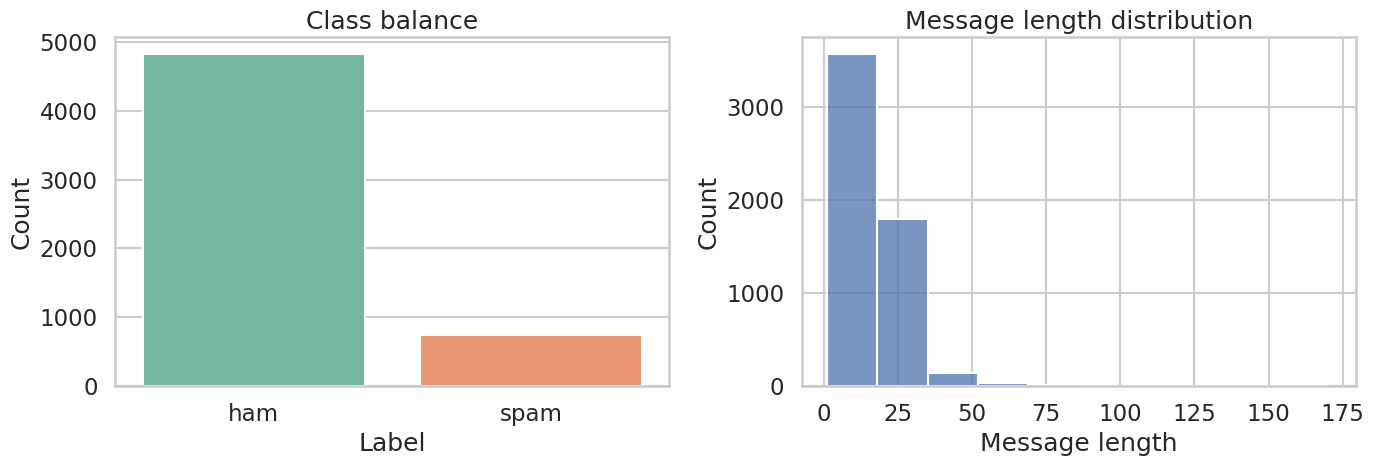

,metric,value
0,minimum length,1.0
1,average length,15.6
2,maximum length,171.0



 Smallest Text :  Yup

 Largest Sentence :  For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later..


In [41]:
df["raw_length"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2,figsize=(14,5))

label_counts = df["label"].value_counts().sort_index()
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Class balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

sns.histplot(df["raw_length"], bins =10, kde=False, color="#4C72B0", ax=axes[1])
axes[1].set_title("Message length distribution")
axes[1].set_xlabel("Message length")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
       {
            "metric": ["minimum length","average length", "maximum length"],
            "value": [
                int(df["raw_length"].min()),
                round(df["raw_length"].mean(),2),
                int(df["raw_length"].max()),
            ],
        }
    )
)
print("\n Smallest Text : ", df[df["raw_length"] == df["raw_length"].min()]["text"].values[0])
print("\n Largest Sentence : ", df[df["raw_length"] == df["raw_length"].max()]["text"].values[0])

## Data Preprocessing

In [5]:
def clean_text(text:str)-> str:
  text = text.lower()
  text = re.sub( r"[^a-z0-9\s]"," ", text)
  text = re.sub(r"\s+"," ", text ).strip()
  return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()


,label,text,raw_length,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah i don t think he goes to usf he lives arou...


In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=RANDOM_SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_df["label"])


## Tokenization

In [7]:
def tokenize(text:str)-> list[str]:
  return text.split()

for split_df in [train_df, val_df, test_df]:
  split_df["tokens"] = split_df["clean_text"].apply(tokenize)

token_counter = Counter(
    token for tokens in train_df["tokens"] for token in tokens
)

word_to_indx = {"<PAD>":0, "<UNK>":1}
for word, _ in token_counter.most_common():
  word_to_indx[word] = len(word_to_indx)

idx_to_word = {idx: word for word, idx in word_to_indx.items()}
PAD_IDX = word_to_indx["<PAD>"]
UNK_IDX = word_to_indx["<UNK>"]

print(f"Vocubulary size (including PAD and UNK): {len(word_to_indx)}")
display(pd.DataFrame(token_counter.most_common(20), columns=["token", "count"]))

Vocubulary size (including PAD and UNK): 7154


,token,count
0,i,2134
1,to,1597
2,you,1557
3,a,1005
4,the,902
5,u,848
6,and,658
7,in,637
8,is,621
9,my,544


In [8]:
from collections import Counter

spam_text = " ".join(df[df['label'] == 'spam']['text'])

words = spam_text.lower().split()

common_words = Counter(words).most_common(10)

print(common_words)

[('to', 685), ('a', 375), ('call', 342), ('your', 263), ('you', 252), ('the', 204), ('for', 202), ('or', 188), ('free', 180), ('2', 169)]


In [9]:
sample_words = ["to","a","call","your","you","the","for","free","or"]
for w in sample_words:
  idx = word_to_indx.get(w, UNK_IDX)
  freq = token_counter.get(w, 0)
  print(f"Word: {w}, Index: {idx}, Frequency: {freq}")

Word: to, Index: 3, Frequency: 1597
Word: a, Index: 5, Frequency: 1005
Word: call, Index: 17, Frequency: 416
Word: your, Index: 15, Frequency: 465
Word: you, Index: 4, Frequency: 1557
Word: the, Index: 6, Frequency: 902
Word: for, Index: 14, Frequency: 489
Word: free, Index: 50, Frequency: 206
Word: or, Index: 32, Frequency: 294


In [10]:
sentence = "Congratulations You won a free prize Claim now"

sentence_tokens = tokenize(sentence.lower())
sentence_ids = [word_to_indx.get(tok, UNK_IDX) for tok in sentence_tokens]
print(f"Sentences : {sentence}")
print(f"Tokens :  {sentence_tokens}")
print(f"Tokens ids : {sentence_ids}")

Sentences : Congratulations You won a free prize Claim now
Tokens :  ['congratulations', 'you', 'won', 'a', 'free', 'prize', 'claim', 'now']
Tokens ids : [764, 4, 155, 5, 50, 175, 132, 23]


In [11]:
decoded = [idx_to_word.get(i, "<?>") for i in sentence_ids]
print(f"Decoded : {decoded}")

Decoded : ['congratulations', 'you', 'won', 'a', 'free', 'prize', 'claim', 'now']


In [12]:
LABEL_TO_ID = {"ham": 0, "spam": 1}
max_length = max(len(tokens) for tokens in train_df["tokens"])


def encode_tokens(tokens: list[str], vocab: dict[str, int]) -> list[int]:
    return [vocab.get(token, UNK_IDX) for token in tokens]


def pad_sequence(encoded_tokens: list[int], max_len: int, pad_idx: int) -> list[int]:
    if len(encoded_tokens) >= max_len:
        return encoded_tokens[:max_len]
    return encoded_tokens + [pad_idx] * (max_len - len(encoded_tokens))


def prepare_split(split_df: pd.DataFrame):
    sequences = []
    lengths = []
    labels = []

    for _, row in split_df.iterrows():
        token_ids = encode_tokens(row["tokens"], word_to_indx)
        effective_length = min(len(token_ids), max_length)
        padded_ids = pad_sequence(token_ids, max_length, PAD_IDX)
        sequences.append(padded_ids)
        lengths.append(effective_length)
        labels.append(LABEL_TO_ID[row["label"]])

    return (
        torch.tensor(sequences, dtype=torch.long),
        torch.tensor(lengths, dtype=torch.long),
        torch.tensor(labels, dtype=torch.float32),
    )


X_train, train_lengths, y_train = prepare_split(train_df)
X_val, val_lengths, y_val = prepare_split(val_df)
X_test, test_lengths, y_test = prepare_split(test_df)

print(f"Max sequence length used for padding: {max_length}")
print(f"Training tensor shape: {tuple(X_train.shape)}")

Max sequence length used for padding: 190
Training tensor shape: (3900, 190)


In [13]:
sample_text = df.loc[0, "text"]
sample_clean = clean_text(sample_text)
sample_tokens = tokenize(sample_clean)
sample_token_ids = encode_tokens(sample_tokens, word_to_indx)
sample_padded = pad_sequence(sample_token_ids, max_length, PAD_IDX)

print("Raw text:")
print(sample_text)
print("\nClean text:")
print(sample_clean)
print("\nTokens:")
print(sample_tokens)
print("\nToken IDs:")
print(sample_token_ids)
print("\nPadded sequence:")
print(sample_padded)

Raw text:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Clean text:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Tokens:
['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']

Token IDs:
[56, 452, 4243, 775, 782, 687, 67, 9, 1515, 89, 116, 332, 1197, 156, 2673, 1649, 64, 59, 4244, 137]

Padded sequence:
[56, 452, 4243, 775, 782, 687, 67, 9, 1515, 89, 116, 332, 1197, 156, 2673, 1649, 64, 59, 4244, 137, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [14]:
BATCH_SIZE = 16

train_dataset = TensorDataset(X_train, train_lengths, y_train)
val_dataset = TensorDataset(X_val, val_lengths, y_val)
test_dataset = TensorDataset(X_test, test_lengths, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 244
Validation batches: 53
Test batches: 53


In [34]:
class SequenceClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        pad_idx: int,
        model_type: str = "RNN",
        dropout: float = 0.2,
    ):
        super().__init__()
        self.model_type = model_type.upper()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        if self.model_type == "RNN":
            self.sequence_layer = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )
        elif self.model_type == "LSTM":
            self.sequence_layer = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )
        elif self.model_type == "GRU":
            self.sequence_layer = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                batch_first=True,
            )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, text_batch, lengths):
        lengths = torch.clamp(lengths, min=1)

        embedded = self.embedding(text_batch)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        if self.model_type == "LSTM":
            _, (hidden, cell_state) = self.sequence_layer(packed)
        else:
            _, hidden = self.sequence_layer(packed)

        last_hidden = hidden[-1]
        logits = self.classifier(self.dropout(last_hidden)).squeeze(1)
        return logits


def batch_accuracy(logits, labels):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    return (predictions == labels).float().mean().item()


def run_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for text_batch, lengths, labels in data_loader:
        text_batch = text_batch.to(DEVICE)
        lengths = lengths.to(DEVICE)
        labels = labels.to(DEVICE)

        valid_mask = lengths > 0
        if not valid_mask.all():
            text_batch = text_batch[valid_mask]
            lengths = lengths[valid_mask]
            labels = labels[valid_mask]

        if len(lengths) == 0:
            continue

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(text_batch, lengths)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item()

        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().astype(int).tolist())
        all_probabilities.extend(probabilities.detach().cpu().numpy().tolist())

    epoch_accuracy = float(
        np.mean(np.array(all_predictions) == np.array(all_labels))
    ) if len(all_predictions) > 0 else 0.0

    return {
        "loss": total_loss / len(data_loader) if len(all_predictions) > 0 else 0.0,
        "accuracy": epoch_accuracy,
        "labels": all_labels,
        "predictions": all_predictions,
        "probabilities": all_probabilities,
    }


def run_experiment(model_type: str, epochs: int = 10, learning_rate: float = 0.003):
    model = SequenceClassifier(
        vocab_size=len(word_to_indx),
        embedding_dim=32,
        hidden_dim=48,
        pad_idx=PAD_IDX,
        model_type=model_type,
        dropout=0.2,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")

    print(f"Training {model_type} model")
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d} | "
            f"train loss: {train_metrics['loss']:.4f} | "
            f"train acc: {train_metrics['accuracy']:.3f} | "
            f"val loss: {val_metrics['loss']:.4f} | "
            f"val acc: {val_metrics['accuracy']:.3f}"
        )

    model.load_state_dict(best_state)
    test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)
    report = classification_report(
        test_metrics["labels"],
        test_metrics["predictions"],
        target_names=["ham", "spam"],
        output_dict=True,
        zero_division=0,
    )

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "report": report,
        "confusion_matrix": confusion_matrix(
            test_metrics["labels"], test_metrics["predictions"]
        ),
    }


def display_results(model_name: str, result: dict):
    print(f"\n{model_name} test loss: {result['test_metrics']['loss']:.4f}")
    print(f"{model_name} test accuracy: {result['test_metrics']['accuracy']:.3f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["ham", "spam"],
        yticklabels=["ham", "spam"],
        ax=ax,
    )
    ax.set_title(f"{model_name} confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()

    report_df = pd.DataFrame(result["report"]).T.round(3)
    print("\nClassification Report:")
    print(report_df)


def predict_text(model, text: str):
    """
    Predict if a text is spam or ham

    Args:
        model: trained SequenceClassifier
        text: input text string

    Returns:
        label: "spam" or "ham"
        probability: confidence score
    """
    model.eval()
    cleaned = clean_text(text)
    tokens = tokenize(cleaned)
    token_ids = encode_tokens(tokens, word_to_indx)

    # Handle empty token sequences
    if len(token_ids) == 0:
        print("Warning: Text resulted in no tokens. Using padding token.")
        token_ids = [PAD_IDX]

    effective_length = min(len(token_ids), max_length)
    padded_ids = pad_sequence(token_ids, max_length, PAD_IDX)

    text_tensor = torch.tensor([padded_ids], dtype=torch.long).to(DEVICE)
    length_tensor = torch.tensor([effective_length], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logit = model(text_tensor, length_tensor)
        probability = torch.sigmoid(logit).item()

    label = "spam" if probability >= 0.5 else "ham"
    return label, probability

results = {}

In [35]:
results["LSTM"] = run_experiment("LSTM", epochs=10, learning_rate=0.003)

Training LSTM model
Epoch 01 | train loss: 0.2579 | train acc: 0.910 | val loss: 0.1337 | val acc: 0.959
Epoch 02 | train loss: 0.0699 | train acc: 0.978 | val loss: 0.1070 | val acc: 0.966
Epoch 03 | train loss: 0.0308 | train acc: 0.990 | val loss: 0.0859 | val acc: 0.976
Epoch 04 | train loss: 0.0156 | train acc: 0.996 | val loss: 0.0604 | val acc: 0.984
Epoch 05 | train loss: 0.0110 | train acc: 0.997 | val loss: 0.0824 | val acc: 0.976
Epoch 06 | train loss: 0.0036 | train acc: 0.999 | val loss: 0.1028 | val acc: 0.977
Epoch 07 | train loss: 0.0018 | train acc: 0.999 | val loss: 0.0897 | val acc: 0.981
Epoch 08 | train loss: 0.0014 | train acc: 1.000 | val loss: 0.1093 | val acc: 0.977
Epoch 09 | train loss: 0.0003 | train acc: 1.000 | val loss: 0.1260 | val acc: 0.978
Epoch 10 | train loss: 0.0003 | train acc: 1.000 | val loss: 0.1134 | val acc: 0.978



LSTM test loss: 0.0650
LSTM test accuracy: 0.978


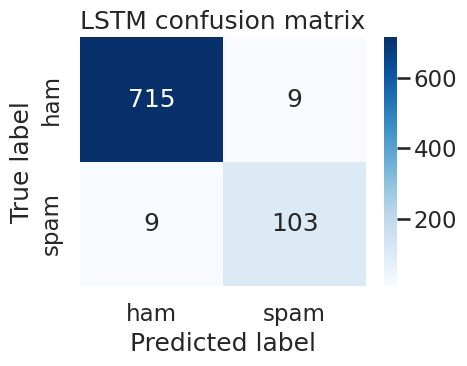


Classification Report:
              precision  recall  f1-score  support
ham               0.988   0.988     0.988  724.000
spam              0.920   0.920     0.920  112.000
accuracy          0.978   0.978     0.978    0.978
macro avg         0.954   0.954     0.954  836.000
weighted avg      0.978   0.978     0.978  836.000


In [36]:
display_results("LSTM", results["LSTM"])